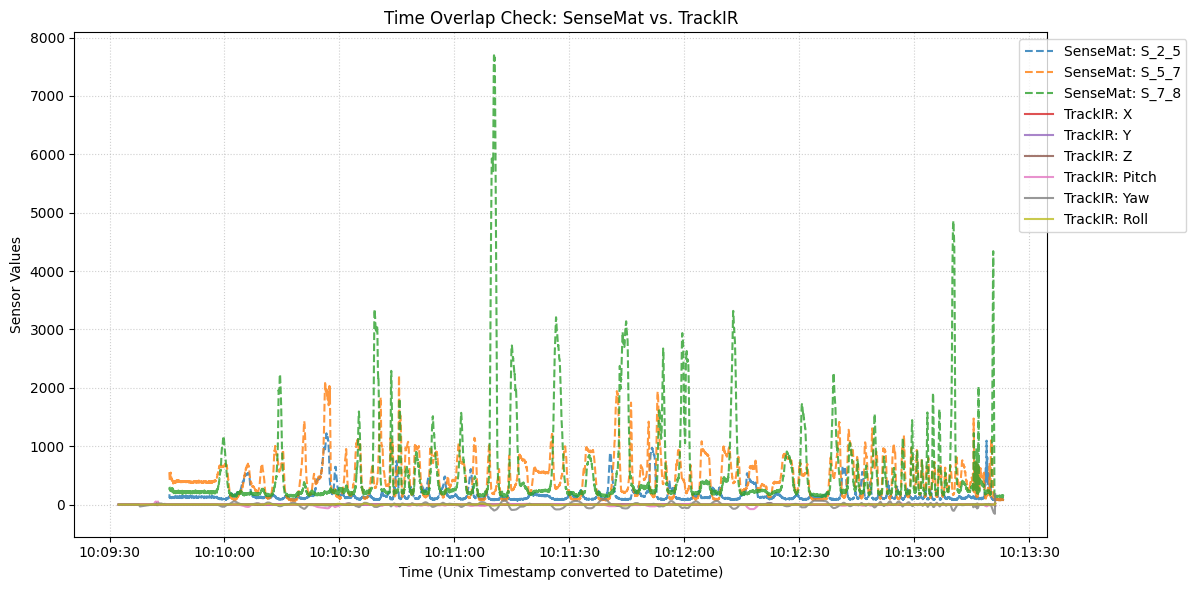

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Define file names
file1 = "Recorded data 22-04\\processed_sensemat_data\\20260422T120945-head-sensemat-serial-log_(WilburLong)_processed.csv"
file2 = "Recorded data 22-04\\20260422_121324_trackir_data (Wilbur long).csv"

# Load the CSV data into pandas DataFrames
try:
    df1 = pd.read_csv(file1, on_bad_lines='skip', skiprows=1)
    df2 = pd.read_csv(file2, on_bad_lines='skip', delimiter=';')
except FileNotFoundError as e:
    print(f"Error loading files: {e}. Please ensure the files are in the same directory as this script.")
    exit()

# 3. Define column names
# SenseMat columns
timestamp_col1 = 'RECV_TIME'
data_cols1 = ['S_2_5', 'S_5_7', 'S_7_8']

# TrackIR columns
timestamp_col2 = 'Unix_Timestamp'
data_cols2 = ['X', 'Y', 'Z', 'Pitch', 'Yaw', 'Roll']

# Preprocessing: Drop rows where the timestamp is empty
df1 = df1.dropna(subset=[timestamp_col1]).reset_index(drop=True)
df2 = df2.dropna(subset=[timestamp_col2]).reset_index(drop=True)

# Conversion: Safely convert the cleaned timestamps to datetime objects
df1['datetime'] = pd.to_datetime(df1[timestamp_col1], unit='s')
df2['datetime'] = pd.to_datetime(df2[timestamp_col2], unit='s')

# Set up the plot
plt.figure(figsize=(12, 6))

# Plot SenseMat data (using dashed lines to distinguish)
for col in data_cols1:
    if col in df1.columns:
        plt.plot(df1['datetime'], df1[col], linestyle='--', label=f'SenseMat: {col}', alpha=0.8)
    else:
        print(f"Warning: Column '{col}' not found in {file1}")

# Plot TrackIR data (using solid lines)
for col in data_cols2:
    if col in df2.columns:
        plt.plot(df2['datetime'], df2[col], linestyle='-', label=f'TrackIR: {col}', alpha=0.8)
    else:
        print(f"Warning: Column '{col}' not found in {file2}")

# 5Formatting the plot
plt.title('Time Overlap Check: SenseMat vs. TrackIR')
plt.xlabel('Time (Unix Timestamp converted to Datetime)')
plt.ylabel('Sensor Values')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()

# Display the plot
plt.show()

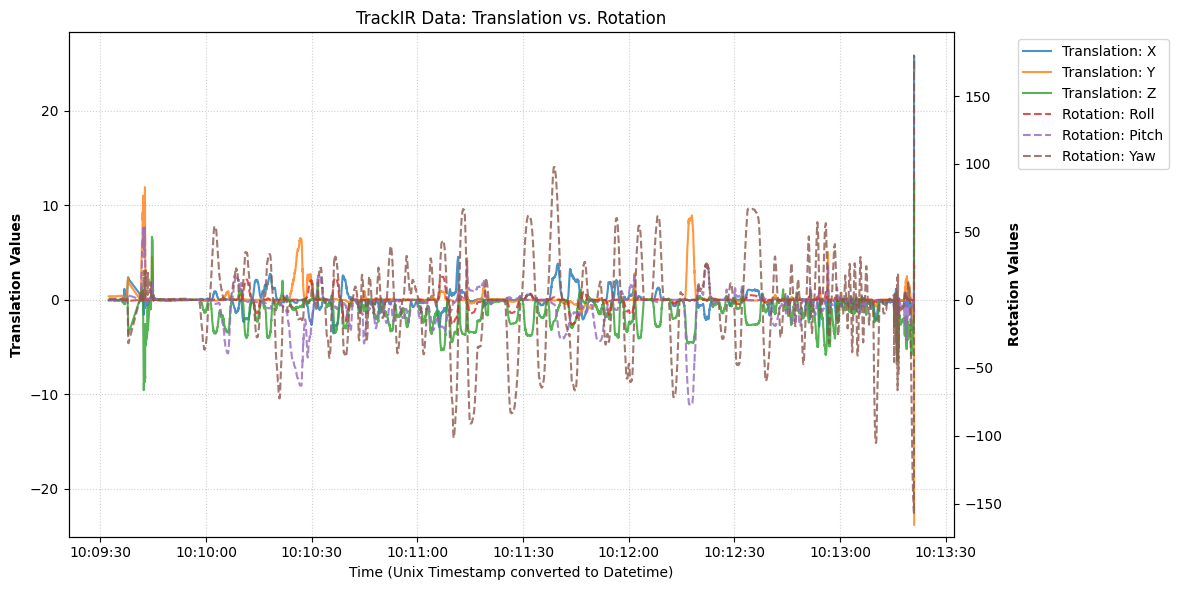

In [20]:
# Split your target columns into Translation and Rotation
trans_cols = ['X', 'Y', 'Z']  
rot_cols = ['Roll', 'Pitch', 'Yaw']  

# Set up the figure and the primary axis (Left Side)
fig, ax1 = plt.subplots(figsize=(12, 6))

color_palette = plt.cm.tab10.colors 
color_idx = 0
lines = []

# Plot Translation data on ax1
for col in trans_cols:
    if col in df2.columns:
        # Using solid lines for translation
        line, = ax1.plot(df2['datetime'], df2[col], linestyle='-', 
                         color=color_palette[color_idx], label=f'Translation: {col}', alpha=0.8)
        lines.append(line)
        color_idx += 1
    else:
        print(f"Warning: Column '{col}' not found in {file2}")

# Format left axis
ax1.set_xlabel('Time (Unix Timestamp converted to Datetime)')
ax1.set_ylabel('Translation Values', fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)

# Set up the secondary axis (Right Side)
ax2 = ax1.twinx()

# Plot Rotation data on ax2
for col in rot_cols:
    if col in df2.columns:
        # Using dashed lines for rotation to easily tell them apart visually
        line, = ax2.plot(df2['datetime'], df2[col], linestyle='--', 
                         color=color_palette[color_idx], label=f'Rotation: {col}', alpha=0.8)
        lines.append(line)
        color_idx += 1
    else:
        print(f"Warning: Column '{col}' not found in {file2}")

# Format right axis
ax2.set_ylabel('Rotation Values', fontweight='bold')

ymin1, ymax1 = ax1.get_ylim()
ymin2, ymax2 = ax2.get_ylim()

# Calculate what percentage of each axis is currently sitting above zero
y1_ratio = ymax1 / (ymax1 - ymin1)
y2_ratio = ymax2 / (ymax2 - ymin2)

# Expand the negative space of whichever axis needs it to make the ratios match
if y1_ratio > y2_ratio:
    ax2.set_ylim(ymax2 - (ymax2 / y1_ratio), ymax2)
else:
    ax1.set_ylim(ymax1 - (ymax1 / y2_ratio), ymax1)

# Combine Legends and Format Plot
# Grab the labels from our saved lines list to make one unified legend
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', bbox_to_anchor=(1.25, 1))

plt.title('TrackIR Data: Translation vs. Rotation')
fig.tight_layout()

# Display the plot
plt.show()